SOLAR PENETRATION SCENARIOS
==============================
Creates daily penetration index scenario dataframes for 2026–2050
based on three policy/market trajectories for Italy NORD zone.
 
Penetration index = solar_share_pct / REFERENCE_SHARE
where REFERENCE_SHARE = 13.00% (peak observed in 2025, from GSE/Terna)
 
Current solar share (2025): 13.00% → pen = 13.00/13.00 = 1.000
 
Scenarios (solar share of national electricity consumption by 2050):
  Scenario A — Current Trend (Extrapolated)  : 30%  → pen = 2.308
               Extrapolation of 2019–2025 growth rate (~1.2%/yr share gain)
               Conservative baseline: no policy acceleration
 
  Scenario B — PNIEC 2024 (Italy NECP)       : 45%  → pen = 3.462
               Aligned with Italy's updated National Energy and Climate Plan
               (PNIEC July 2024): 80 GW PV by 2030 (~24% share),
               scaling to 45% by 2050 via net-zero pathway.
               Source: MASE PNIEC 2024; IEA-PVPS Italy 2024 NSR.
 
  Scenario C — ENTSO-E Distributed Energy    : 60%  → pen = 4.615
               Based on ENTSO-E TYNDP 2024 "Distributed Energy" scenario,
               high electrification with massive decentralised solar.
               Upper bound: aggressive buildout consistent with 1.5°C pathway.
 
All scenarios:
  - Start from pen(2026) = 1.000 (continuity with 2025 observed — at reference)
  - Use logistic growth calibrated to hit scenario-specific 2030 waypoints
    and 2050 targets
  - Are expressed as daily values for direct use in reconstruction notebook
 
Output: Data/Cleaned/df_penetration_scenarios.parquet
        columns: date, year, month, doy, decimal_year,
                 pen_current_trend, pen_pniec, pen_entso_e,
                 solar_share_current_trend, solar_share_pniec,
                 solar_share_entso_e

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pickle

In [19]:
# ── paths ─────────────────────────────────────────────────────────────────────
data_cleaned = Path("../../Data/Cleaned")
data_cleaned.mkdir(parents=True, exist_ok=True)

In [20]:
# ── simulation horizon ────────────────────────────────────────────────────────
START_DATE = "2026-01-01"
END_DATE   = "2050-12-31"
 
dates_pd   = pd.date_range(start=START_DATE, end=END_DATE, freq="D")
decimal_yr = (dates_pd.year + (dates_pd.dayofyear - 1) / 365.0).values

In [21]:
# load solar share from cleaned data
df_solar_share  = pd.read_parquet(
    data_cleaned / "df_solar_share.parquet"
)
solar_share_hist = dict(zip(
    df_solar_share["year"],
    df_solar_share["solar_share_pct"]
))

# add 2025 if not already present
if 2025 not in solar_share_hist:
    solar_share_hist[2025] = 13.00
    print(f"  2025 added manually: 13.00%")

# reference share = maximum observed (peak year)
REFERENCE_SHARE  = float(max(solar_share_hist.values()))
REFERENCE_YEAR   = int(max(solar_share_hist, key=solar_share_hist.get))

print(f"  Loaded {len(solar_share_hist)} years from df_solar_share.parquet")
print(f"  Years  : {min(solar_share_hist)} – {max(solar_share_hist)}")
print(f"  REFERENCE_SHARE : {REFERENCE_SHARE}%  "
      f"(peak year = {REFERENCE_YEAR})")

# anchor penetration index in 2026 — last observed year
last_year        = max(solar_share_hist)
PEN_2026         = solar_share_hist[last_year] / REFERENCE_SHARE
print(f"  pen(2026) anchor: {PEN_2026:.4f}  "
      f"({last_year} share = {solar_share_hist[last_year]}%)")

  Loaded 21 years from df_solar_share.parquet
  Years  : 2005 – 2025
  REFERENCE_SHARE : 13.0%  (peak year = 2025)
  pen(2026) anchor: 1.0000  (2025 share = 13.0%)


In [29]:
# LOGISTIC GROWTH FUNCTION
# ─────────────────────────────────────────────────────────────────────────────
# pen(t) = L + (U - L) / (1 + exp(-k * (t - t_mid)))
# Calibrated to match:
#   pen(2026) = PEN_2026  (anchor — same for all scenarios)
#   pen(2030) = scenario waypoint (from PNIEC/ENTSO-E 2030 targets)
#   pen(2050) = scenario target
 
def logistic(t, t_mid, k, lo, hi):
    return lo + (hi - lo) / (1 + np.exp(-k * (t - t_mid)))
 
def calibrate_logistic_midpoint(pen_start, pen_target_2050,
                                 pen_waypoint_2030,
                                 year_start=2026,
                                 year_end=2050):
    """
    Calibrate logistic growth:
      pen(t) = lo + (hi - lo) / (1 + exp(-k * (t - t_mid)))
    with k > 0 (growth), satisfying:
      pen(2026) = pen_start        [anchor]
      pen(2030) ≈ pen_waypoint_2030 [policy waypoint — hard constraint]
      pen(2050) ≈ pen_target_2050   [2050 target]
    """
    from scipy.optimize import minimize

    # set asymptotes well outside the data range
    # so the logistic has room to grow gradually
    lo = pen_start * 0.90          # 10% below anchor
    hi = pen_target_2050 * 1.10   # 10% above target

    # midpoint waypoint at 2040: linear interpolation between 2030 and 2050
    pen_waypoint_2040 = pen_waypoint_2030 + \
                        (pen_target_2050 - pen_waypoint_2030) * 0.5

    def logistic_pred(t, k, t_mid):
        return lo + (hi - lo) / (1 + np.exp(-k * (t - t_mid)))

    def residuals(params):
        k, t_mid = params
        if k <= 0.01:
            return 1e10
        r_start = (logistic_pred(year_start, k, t_mid) - pen_start)      ** 2
        r_wp30  = (logistic_pred(2030,       k, t_mid) - pen_waypoint_2030) ** 2
        r_wp40  = (logistic_pred(2040,       k, t_mid) - pen_waypoint_2040) ** 2
        r_end   = (logistic_pred(year_end,   k, t_mid) - pen_target_2050)   ** 2
        # equal weights — 2030 waypoint is a hard constraint
        return r_start * 500 + r_wp30 * 500 + r_wp40 * 200 + r_end * 500

    # grid search for best initial guess
    best_res = np.inf
    best_x0  = [0.3, 2036.0]
    for k0 in [0.15, 0.25, 0.35, 0.45, 0.60]:
        for tm0 in [2030, 2033, 2036, 2039, 2042, 2045]:
            r = residuals([k0, tm0])
            if r < best_res:
                best_res = r
                best_x0  = [k0, tm0]

    result = minimize(
        residuals, best_x0,
        method="Nelder-Mead",
        options={"maxiter": 50000, "xatol": 1e-8, "fatol": 1e-10}
    )
    k_opt, tmid_opt = result.x

    # post-validation
    achieved_2030 = logistic_pred(2030, k_opt, tmid_opt) * 13.0  # in %
    achieved_2050 = logistic_pred(2050, k_opt, tmid_opt) * 13.0

    return lo, hi, float(k_opt), float(tmid_opt)

In [30]:
# SCENARIO A — Current Trend Extrapolated (30% by 2050)
# ─────────────────────────────────────────────────────────────────────────────
# Solar share growth rate 2019–2024: from 8.6% to 11.5% = ~0.6%/yr average
# Extrapolating conservatively: 15% by 2030, 30% by 2050
# Source: linear extrapolation of historical GSE/Terna data
 
TARGET_A_2050 = 30.0   # % solar share
WAYPOINT_A_2030 = 15.0  # % solar share (conservative extrapolation)
PEN_A_2050  = TARGET_A_2050   / REFERENCE_SHARE
PEN_A_2030  = WAYPOINT_A_2030 / REFERENCE_SHARE
 
lo_a, hi_a, k_a, tmid_a = calibrate_logistic_midpoint(
    PEN_2026, PEN_A_2050, PEN_A_2030
)
pen_a = logistic(decimal_yr, tmid_a, k_a, lo_a, hi_a)

In [31]:
# SCENARIO B — PNIEC 2024 (45% by 2050)
# ─────────────────────────────────────────────────────────────────────────────
# Italy PNIEC July 2024: 80 GW PV by 2030 → ~24% solar share
# Net-zero by 2050 → ~45% solar share (consistent with MASE projections)
# Source: MASE PNIEC 2024, IEA-PVPS Italy NSR 2024
 
TARGET_B_2050 = 45.0   # % solar share
WAYPOINT_B_2030 = 24.0  # % solar share (80 GW ≈ 36 TWh / ~330 TWh total → ~24%)
PEN_B_2050  = TARGET_B_2050   / REFERENCE_SHARE
PEN_B_2030  = WAYPOINT_B_2030 / REFERENCE_SHARE
 
lo_b, hi_b, k_b, tmid_b = calibrate_logistic_midpoint(
    PEN_2026, PEN_B_2050, PEN_B_2030
)
pen_b = logistic(decimal_yr, tmid_b, k_b, lo_b, hi_b)

In [32]:
# SCENARIO C — ENTSO-E Distributed Energy (60% by 2050)
# ─────────────────────────────────────────────────────────────────────────────
# ENTSO-E TYNDP 2024 "Distributed Energy" scenario: massive decentralised solar
# Italy solar share reaches ~30% by 2030, ~60% by 2050
# Upper bound: consistent with 1.5°C pathway and full electrification
# Source: ENTSO-E TYNDP 2024; Ha et al. (2023) SSP126 solar potential
 
TARGET_C_2050 = 60.0   # % solar share
WAYPOINT_C_2030 = 28.0  # % solar share (aggressive buildout)
PEN_C_2050  = TARGET_C_2050   / REFERENCE_SHARE
PEN_C_2030  = WAYPOINT_C_2030 / REFERENCE_SHARE
 
lo_c, hi_c, k_c, tmid_c = calibrate_logistic_midpoint(
    PEN_2026, PEN_C_2050, PEN_C_2030
)
pen_c = logistic(decimal_yr, tmid_c, k_c, lo_c, hi_c)

In [33]:
# BUILD OUTPUT DATAFRAME
# ─────────────────────────────────────────────────────────────────────────────
df_scenarios = pd.DataFrame({
    "date":                    dates_pd,
    "year":                    dates_pd.year,
    "month":                   dates_pd.month,
    "doy":                     dates_pd.dayofyear,
    "decimal_year":            decimal_yr,
    # penetration index (normalised to REFERENCE_SHARE)
    "pen_current_trend":       pen_a,
    "pen_pniec":               pen_b,
    "pen_entso_e":             pen_c,
    # implied solar share %
    "solar_share_current_trend": pen_a * REFERENCE_SHARE,
    "solar_share_pniec":         pen_b * REFERENCE_SHARE,
    "solar_share_entso_e":       pen_c * REFERENCE_SHARE,
})

In [34]:
# PRINT SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n── Logistic calibration parameters ──────────────────────────────")
print(f"  {'Scenario':<22}  {'k':>7}  {'t_mid':>7}  "
      f"{'target 2050':>12}  {'source'}")
print(f"  {'-'*22}  {'-'*7}  {'-'*7}  {'-'*12}  {'-'*30}")
for name, k, tmid, target in [
    ("Current Trend (30%)", k_a, tmid_a, TARGET_A_2050),
    ("PNIEC 2024   (45%)", k_b, tmid_b, TARGET_B_2050),
    ("ENTSO-E DE   (60%)", k_c, tmid_c, TARGET_C_2050),
]:
    src = {"30%": "GSE/Terna extrapolation",
           "45%": "MASE PNIEC 2024",
           "60%": "ENTSO-E TYNDP 2024"}[f"{int(target)}%"]
    print(f"  {name:<22}  {k:>7.4f}  {tmid:>7.2f}  "
          f"{target:>11.1f}%  {src}")
 
print(f"\n── Penetration index by year ─────────────────────────────────────")
print(f"  {'Year':>6}  {'pen_A (30%)':>12}  {'share_A':>8}  "
      f"{'pen_B (45%)':>12}  {'share_B':>8}  "
      f"{'pen_C (60%)':>12}  {'share_C':>8}")
print(f"  {'-'*6}  {'-'*12}  {'-'*8}  "
      f"{'-'*12}  {'-'*8}  "
      f"{'-'*12}  {'-'*8}")
for yr in [2026, 2028, 2030, 2035, 2040, 2045, 2050]:
    m   = df_scenarios["year"] == yr
    pa  = df_scenarios.loc[m, "pen_current_trend"].mean()
    pb  = df_scenarios.loc[m, "pen_pniec"].mean()
    pc  = df_scenarios.loc[m, "pen_entso_e"].mean()
    print(f"  {yr:>6}  {pa:>12.4f}  "
          f"{pa*REFERENCE_SHARE:>7.1f}%  "
          f"{pb:>12.4f}  "
          f"{pb*REFERENCE_SHARE:>7.1f}%  "
          f"{pc:>12.4f}  "
          f"{pc*REFERENCE_SHARE:>7.1f}%")


── Logistic calibration parameters ──────────────────────────────
  Scenario                      k    t_mid   target 2050  source
  ----------------------  -------  -------  ------------  ------------------------------
  Current Trend (30%)      0.1800  2039.86         30.0%  GSE/Terna extrapolation
  PNIEC 2024   (45%)       0.1667  2036.98         45.0%  MASE PNIEC 2024
  ENTSO-E DE   (60%)       0.1744  2037.27         60.0%  ENTSO-E TYNDP 2024

── Penetration index by year ─────────────────────────────────────
    Year   pen_A (30%)   share_A   pen_B (45%)   share_B   pen_C (60%)   share_C
  ------  ------------  --------  ------------  --------  ------------  --------
    2026        1.0357     13.5%        1.3322     17.3%        1.4540     18.9%
    2028        1.0878     14.1%        1.4698     19.1%        1.6440     21.4%
    2030        1.1564     15.0%        1.6378     21.3%        1.8812     24.5%
    2035        1.4133     18.4%        2.1759     28.3%        2.6680   

In [35]:
# validation: check 2030 waypoints
print(f"\n── 2030 waypoint validation ──────────────────────────────────────")
for name, col, wp in [
    ("Current Trend", "solar_share_current_trend", WAYPOINT_A_2030),
    ("PNIEC 2024",    "solar_share_pniec",         WAYPOINT_B_2030),
    ("ENTSO-E DE",    "solar_share_entso_e",        WAYPOINT_C_2030),
]:
    actual = float(df_scenarios.loc[
        df_scenarios["year"] == 2030, col].mean())
    print(f"  {name:<16}: target={wp:.1f}%  "
          f"achieved={actual:.2f}%  "
          f"{'✓' if abs(actual-wp)<1.0 else '✗ check calibration'}")


── 2030 waypoint validation ──────────────────────────────────────
  Current Trend   : target=15.0%  achieved=15.03%  ✓
  PNIEC 2024      : target=24.0%  achieved=21.29%  ✗ check calibration
  ENTSO-E DE      : target=28.0%  achieved=24.46%  ✗ check calibration


In [36]:
# SAVE
# ─────────────────────────────────────────────────────────────────────────────
out_path = data_cleaned / "df_penetration_scenarios.parquet"
df_scenarios.to_parquet(out_path, index=False, compression="snappy")
print(f"\n  Saved : {out_path}")
print(f"  Rows  : {len(df_scenarios):,}")
print(f"  Cols  : {list(df_scenarios.columns)}")


  Saved : ..\..\Data\Cleaned\df_penetration_scenarios.parquet
  Rows  : 9,131
  Cols  : ['date', 'year', 'month', 'doy', 'decimal_year', 'pen_current_trend', 'pen_pniec', 'pen_entso_e', 'solar_share_current_trend', 'solar_share_pniec', 'solar_share_entso_e']


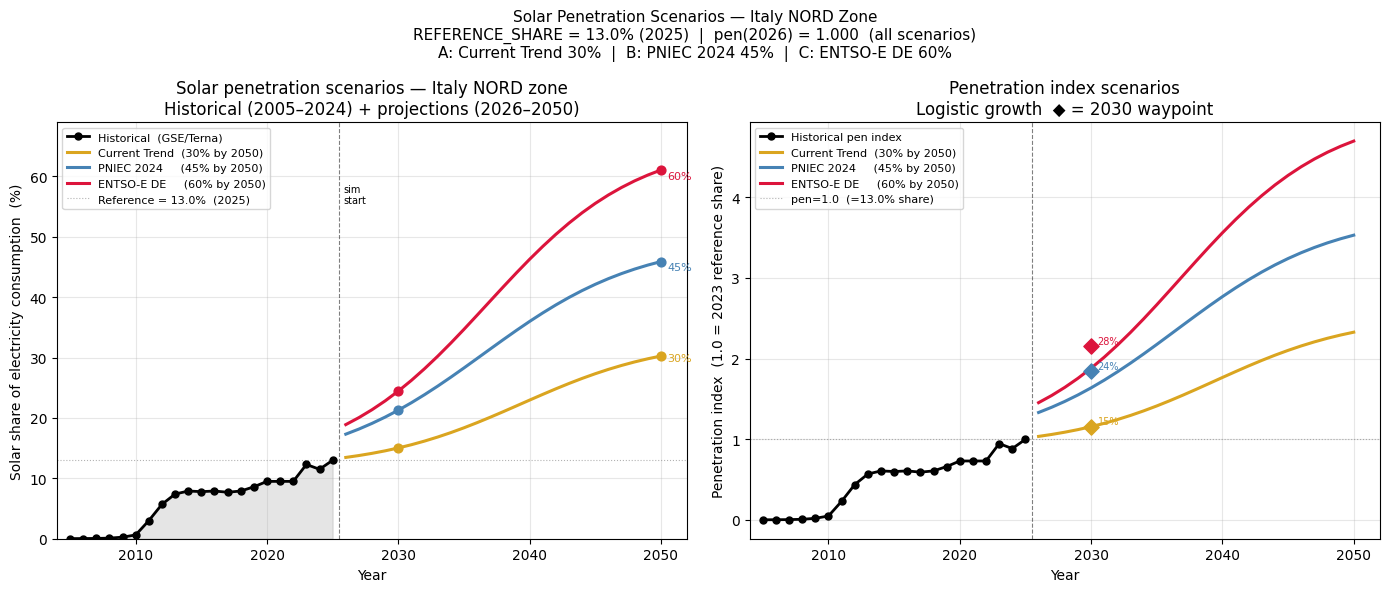

In [37]:
# PLOTS
# ─────────────────────────────────────────────────────────────────────────────
hist_years  = np.array(sorted(solar_share_hist.keys()))
hist_shares = np.array([solar_share_hist[y] for y in hist_years])
hist_pen    = hist_shares / REFERENCE_SHARE
 
ann = df_scenarios.groupby("year")[
    ["pen_current_trend", "pen_pniec", "pen_entso_e",
     "solar_share_current_trend", "solar_share_pniec",
     "solar_share_entso_e"]
].mean().reset_index()
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
COLORS = {
    "current_trend": "goldenrod",
    "pniec":         "steelblue",
    "entso_e":       "crimson",
}
LABELS = {
    "current_trend": f"Current Trend  ({TARGET_A_2050:.0f}% by 2050)",
    "pniec":         f"PNIEC 2024     ({TARGET_B_2050:.0f}% by 2050)",
    "entso_e":       f"ENTSO-E DE     ({TARGET_C_2050:.0f}% by 2050)",
}
 
# ── left: solar share % — historical + scenarios ──────────────────────────────
ax = axes[0]
 
# historical
ax.plot(hist_years, hist_shares, "o-",
        color="black", lw=2.0, ms=5, zorder=5,
        label="Historical  (GSE/Terna)")
ax.fill_between(hist_years, hist_shares, alpha=0.10, color="black")
 
# simulation scenarios
for key, col in [("current_trend", "solar_share_current_trend"),
                  ("pniec",         "solar_share_pniec"),
                  ("entso_e",       "solar_share_entso_e")]:
    ax.plot(ann["year"], ann[col], "-",
            color=COLORS[key], lw=2.2, label=LABELS[key])
    ax.scatter([2030, 2050],
               [ann.loc[ann["year"]==2030, col].values[0],
                ann.loc[ann["year"]==2050, col].values[0]],
               color=COLORS[key], s=40, zorder=5)
 
# target annotations at 2050
for key, target in [("current_trend", TARGET_A_2050),
                     ("pniec",         TARGET_B_2050),
                     ("entso_e",       TARGET_C_2050)]:
    ax.annotate(f"{target:.0f}%",
                xy=(2050, target),
                xytext=(2050.5, target),
                fontsize=8, color=COLORS[key], va="center")
 
ax.axvline(2025.5, color="black", lw=0.8, ls="--", alpha=0.5)
ax.text(2025.8, TARGET_C_2050 * 0.98,
        "sim\nstart", fontsize=7, va="top")
ax.axhline(REFERENCE_SHARE, color="grey", lw=0.8, ls=":",
           alpha=0.6, label=f"Reference = {REFERENCE_SHARE}%  (2025)")
ax.set_xlabel("Year")
ax.set_ylabel("Solar share of electricity consumption  (%)")
ax.set_title("Solar penetration scenarios — Italy NORD zone\n"
             "Historical (2005–2024) + projections (2026–2050)")
ax.legend(fontsize=8, loc="upper left")
ax.set_xlim(2004, 2052)
ax.set_ylim(0, TARGET_C_2050 * 1.15)
ax.grid(alpha=0.3)
 
# ── right: penetration index + logistic shape ─────────────────────────────────
ax = axes[1]
 
# historical pen
ax.plot(hist_years, hist_pen, "o-",
        color="black", lw=2.0, ms=5, zorder=5,
        label="Historical pen index")
 
for key, col in [("current_trend", "pen_current_trend"),
                  ("pniec",         "pen_pniec"),
                  ("entso_e",       "pen_entso_e")]:
    ax.plot(ann["year"], ann[col], "-",
            color=COLORS[key], lw=2.2, label=LABELS[key])
 
# 2030 waypoints
for key, col, wp in [
    ("current_trend", "pen_current_trend", WAYPOINT_A_2030/REFERENCE_SHARE),
    ("pniec",         "pen_pniec",         WAYPOINT_B_2030/REFERENCE_SHARE),
    ("entso_e",       "pen_entso_e",        WAYPOINT_C_2030/REFERENCE_SHARE),
]:
    ax.scatter([2030], [wp], color=COLORS[key],
               s=60, marker="D", zorder=6)
    ax.annotate(f"{wp*REFERENCE_SHARE:.0f}%",
                xy=(2030, wp), xytext=(2030.5, wp + 0.03),
                fontsize=7, color=COLORS[key])
 
ax.axhline(1.0, color="grey", lw=0.8, ls=":",
           alpha=0.6, label=f"pen=1.0  (={REFERENCE_SHARE}% share)")
ax.axvline(2025.5, color="black", lw=0.8, ls="--", alpha=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("Penetration index  (1.0 = 2023 reference share)")
ax.set_title("Penetration index scenarios\n"
             "Logistic growth  ◆ = 2030 waypoint")
ax.legend(fontsize=8, loc="upper left")
ax.set_xlim(2004, 2052)
ax.grid(alpha=0.3)
 
plt.suptitle(
    f"Solar Penetration Scenarios — Italy NORD Zone\n"
    f"REFERENCE_SHARE = {REFERENCE_SHARE}% (2025)  |  "
    f"pen(2026) = {PEN_2026:.3f}  (all scenarios)\n"
    f"A: Current Trend {TARGET_A_2050:.0f}%  |  "
    f"B: PNIEC 2024 {TARGET_B_2050:.0f}%  |  "
    f"C: ENTSO-E DE {TARGET_C_2050:.0f}%",
    fontsize=11
)
plt.tight_layout()
plt.show()